## YZTA DATATHON EDA 

Kütüphaneler

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Veri setlerini aktarma

In [9]:
trainset = pd.read_csv('train.csv')
testset = pd.read_csv('test_x.csv')

Veri hakkında bilgiler


In [17]:
trainset.head(5)

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [16]:
trainset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

In [19]:
trainset.isnull().sum()

id                                0
yas                               0
cinsiyet                          0
meslek                         1378
vucut_kitle_indeksi            1752
ulke                              0
rem_yuzdesi                       0
derin_uyku_yuzdesi                0
uykuya_dalma_suresi_dk            0
gecelik_uyanma_sayisi             0
uyku_oncesi_kafein_mg          1463
uyku_oncesi_ekran_suresi_dk       0
gunluk_adim_sayisi                0
sekerleme_suresi_dk               0
stres_skoru                    1715
gunluk_calisma_saati              0
kronotip                       1968
ruh_sagligi_durumu             1096
dinlenik_nabiz_bpm                0
oda_sicakligi_celsius             0
hafta_sonu_uyku_farki_saat        0
mevsim                            0
gun_tipi                          0
bilissel_performans_skoru         0
dtype: int64

In [20]:
testset.isnull().sum()

id                               0
yas                              0
cinsiyet                         0
meslek                         622
vucut_kitle_indeksi            648
ulke                             0
rem_yuzdesi                      0
derin_uyku_yuzdesi               0
uykuya_dalma_suresi_dk           0
gecelik_uyanma_sayisi            0
uyku_oncesi_kafein_mg          697
uyku_oncesi_ekran_suresi_dk      0
gunluk_adim_sayisi               0
sekerleme_suresi_dk              0
stres_skoru                    765
gunluk_calisma_saati             0
kronotip                       832
ruh_sagligi_durumu             504
dinlenik_nabiz_bpm               0
oda_sicakligi_celsius            0
hafta_sonu_uyku_farki_saat       0
mevsim                           0
gun_tipi                         0
dtype: int64

### Eksik verilerin temizlenmesi.
Data leakage yaşamamak ve test verisinin hiç görülmemesi için testteki sayısal metrikleri train verisinin medyanına göre doldur.
Aykırı değerlerden etkilenmemek için medyan kullan.
Kategorik verilerde moda göre doldurma yap.




In [25]:
# Sayısal ve Kategorik kolonları belirleyelim
sayisal_eksikler = ['vucut_kitle_indeksi', 'uyku_oncesi_kafein_mg', 'stres_skoru']
kategorik_eksikler = ['meslek', 'kronotip', 'ruh_sagligi_durumu']

# 1. Sayısal kolonları TRAIN setinin MEDYAN'ı ile doldurma
for col in sayisal_eksikler:
    medyan_deger = trainset[col].median()
    # inplace=True yerine değişkenin kendisinin üzerine yazıyoruz
    trainset[col] = trainset[col].fillna(medyan_deger)
    testset[col] = testset[col].fillna(medyan_deger)

# 2. Kategorik kolonları TRAIN setinin MOD'u ile doldurma
for col in kategorik_eksikler:
    mod_deger = trainset[col].mode()[0]
    # inplace=True yerine değişkenin kendisinin üzerine yazıyoruz
    trainset[col] = trainset[col].fillna(mod_deger)
    testset[col] = testset[col].fillna(mod_deger)



Boşlukları kontrol edelim.

In [26]:
trainset.isnull().sum()


id                             0
yas                            0
cinsiyet                       0
meslek                         0
vucut_kitle_indeksi            0
ulke                           0
rem_yuzdesi                    0
derin_uyku_yuzdesi             0
uykuya_dalma_suresi_dk         0
gecelik_uyanma_sayisi          0
uyku_oncesi_kafein_mg          0
uyku_oncesi_ekran_suresi_dk    0
gunluk_adim_sayisi             0
sekerleme_suresi_dk            0
stres_skoru                    0
gunluk_calisma_saati           0
kronotip                       0
ruh_sagligi_durumu             0
dinlenik_nabiz_bpm             0
oda_sicakligi_celsius          0
hafta_sonu_uyku_farki_saat     0
mevsim                         0
gun_tipi                       0
bilissel_performans_skoru      0
dtype: int64

In [27]:
 testset.isnull().sum()

id                             0
yas                            0
cinsiyet                       0
meslek                         0
vucut_kitle_indeksi            0
ulke                           0
rem_yuzdesi                    0
derin_uyku_yuzdesi             0
uykuya_dalma_suresi_dk         0
gecelik_uyanma_sayisi          0
uyku_oncesi_kafein_mg          0
uyku_oncesi_ekran_suresi_dk    0
gunluk_adim_sayisi             0
sekerleme_suresi_dk            0
stres_skoru                    0
gunluk_calisma_saati           0
kronotip                       0
ruh_sagligi_durumu             0
dinlenik_nabiz_bpm             0
oda_sicakligi_celsius          0
hafta_sonu_uyku_farki_saat     0
mevsim                         0
gun_tipi                       0
dtype: int64

## Temizlediğimiz setteki kategorik verileri hangi yöntemle sınıflandıracağımızı seçelim.


In [28]:
kategorik_kolonlar = trainset.select_dtypes(include=['object', 'category']).columns

print("KATEGORİK DEĞİŞKENLERİN DETAYLI İNCELEMESİ\n" + "="*40)

for col in kategorik_kolonlar:
    benzersiz_degerler = trainset[col].unique()
    kategori_sayisi = trainset[col].nunique()
    
    print(f"Kolon Adı: {col.upper()}")
    print(f"Toplam Kategori Sayısı: {kategori_sayisi}")
    print(f"Kategoriler: {benzersiz_degerler}\n")
    print("-" * 40)

KATEGORİK DEĞİŞKENLERİN DETAYLI İNCELEMESİ
Kolon Adı: CINSIYET
Toplam Kategori Sayısı: 2
Kategoriler: ['Erkek' 'Kadin']

----------------------------------------
Kolon Adı: MESLEK
Toplam Kategori Sayısı: 11
Kategoriler: ['Saglik Personeli' 'Muhendis' 'Ev Hanimi' 'Egitimci'
 'Satis ve Pazarlama Calisani' 'Yonetici' 'Lawyer' 'Emekli' 'Ogrenci'
 'Lojistik Calisani' 'Serbest Calisan']

----------------------------------------
Kolon Adı: ULKE
Toplam Kategori Sayısı: 15
Kategoriler: ['Cin' 'Amerika' 'Spain' 'Yeni Zelanda' 'Portekiz' 'South Korea' 'Fransa'
 'Ispanya' 'Ingiltere' 'Netherlands' 'Arjantin' 'Guney Kore' 'Isvec'
 'Sweden' 'Mexico']

----------------------------------------
Kolon Adı: KRONOTIP
Toplam Kategori Sayısı: 3
Kategoriler: ['Sabah insani' 'Gece insani' 'Notr']

----------------------------------------
Kolon Adı: RUH_SAGLIGI_DURUMU
Toplam Kategori Sayısı: 4
Kategoriler: ['Anksiyete ve depresyon' 'Saglikli' 'Depresyon' 'Anksiyete']

----------------------------------------
K

### Kategorik değişkenlerimize encoding uygulayalım
Ruh sağlığı durumu için ordinal encoding.
Kalan değişkenler için one-hot encoding uygulayalım.

In [1]:
# 1. RUH SAĞLIĞI İÇİN ORDINAL ENCODING (Hiyerarşik Sıralama)
ruh_sagligi_siralamasi = {
    'Anksiyete ve depresyon': 1,
    'Depresyon': 2,
    'Anksiyete': 3,
    'Saglikli': 4
}

# Map fonksiyonu ile metinleri sayılara çeviriyoruz
trainset['ruh_sagligi_durumu'] = trainset['ruh_sagligi_durumu'].map(ruh_sagligi_siralamasi)
testset['ruh_sagligi_durumu'] = testset['ruh_sagligi_durumu'].map(ruh_sagligi_siralamasi)


# 2. GERİ KALAN TÜM KATEGORİKLER İÇİN ONE-HOT ENCODING
ohe_yapilacak_kolonlar = ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'mevsim', 'gun_tipi']

# İki seti de encode edelim (drop_first=True Dummy Tuzağını önler)
train_encoded = pd.get_dummies(trainset, columns=ohe_yapilacak_kolonlar, drop_first=True)
test_encoded = pd.get_dummies(testset, columns=ohe_yapilacak_kolonlar, drop_first=True)

# 3. TRAIN VE TEST SETLERİNİ HİZALAMA (Kritik Adım)
# Eğer test setinde örneğin "Avukat" yoksa ama train'de varsa, model hata verir.
# Bu kod iki taraftaki kolonların birebir aynı olmasını sağlar. Olmayanları 0 ile doldurur.
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# Test setine hizalama sırasında yanlışlıkla ekleme yapıldıysa kaldırma
if 'bilissel_performans_skoru' in test_encoded.columns:
    test_encoded.drop('bilissel_performans_skoru', axis=1, inplace=True)

# Yeni setimizin satır/sütun sayısı
print("Train Seti Boyutu:", train_encoded.shape)
print("Test Seti Boyutu:", test_encoded.shape)

NameError: name 'trainset' is not defined

## Korelasyon haritamızı oluşturalım.


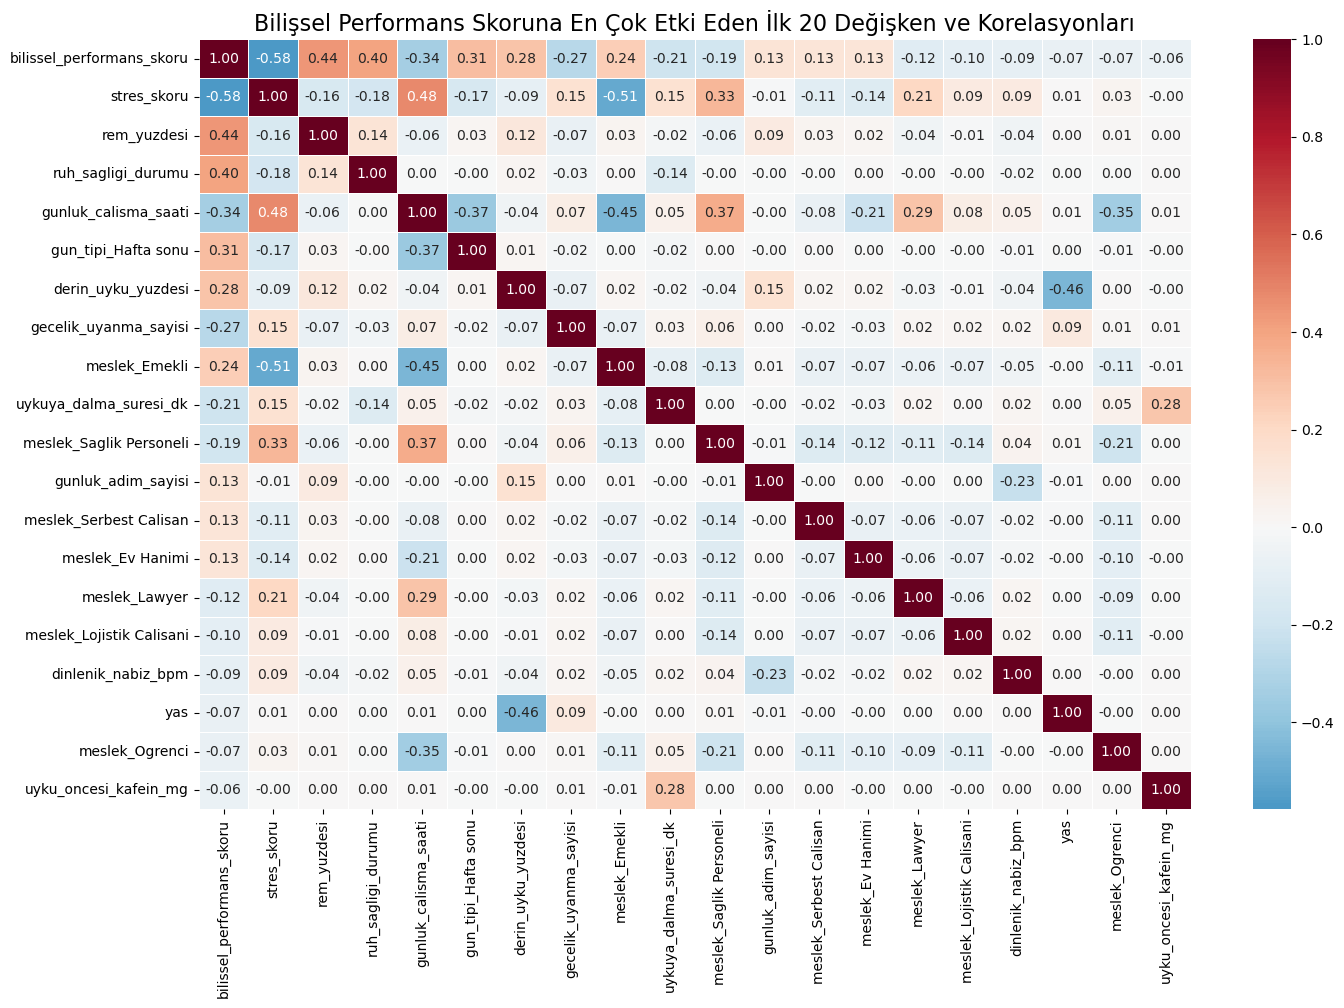

In [30]:
# 1. Hedef değişkenle (bilissel_performans_skoru) en yüksek korelasyona sahip ilk 20 özelliği bulalım
top_corr_features = train_encoded.corr()['bilissel_performans_skoru'].abs().sort_values(ascending=False).head(20).index

# 2. Bu 20 özelliğin kendi aralarındaki korelasyon matrisini hesaplayalım
plt.figure(figsize=(16, 10))
correlation_matrix = train_encoded[top_corr_features].corr()

# 3. Heatmap çizimi
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r', # Kırmızı (pozitif) - Mavi (negatif) dengesi
            center=0, 
            fmt=".2f", 
            linewidths=0.5)

plt.title('Bilişsel Performans Skoruna En Çok Etki Eden İlk 20 Değişken ve Korelasyonları', fontsize=16)
plt.show()

Korelasyon haritamızda görebileceğimiz üzere bilişsel performans skorunu en çok etkileyen değişkenlerimiz:
Negatif yönde: Stres skoru, günlük çalışma saati, gecelik uyanma sayısı ve uykuya dalma süresi.

Pozitif yönde: REM yüzdesi, ruh sağlığı skoru, ve günün haftasonu olması.

Ayrıca meslek gruplarında emeklilik, ev hanımlığı ve serbest meslek gibi üst gruplara bağlı olmayan mesleklerde sağlık ve avukatlık gibi mesleklere göre bilişsel performans skorunda olumlu etki gözlenmiştir.

## Temizlemiş olduğumuz veri setini modellemede kullanmak için dışa aktaralım.

In [31]:
train_encoded.to_csv('train_ready.csv', index=False)
test_encoded.to_csv('test_ready.csv', index=False)

print("Modelleme için veriler hazır! 'train_ready.csv' ve 'test_ready.csv' dosyaları klasöründe oluşturuldu.")

Modelleme için veriler hazır! 'train_ready.csv' ve 'test_ready.csv' dosyaları klasöründe oluşturuldu.
